# Visualización de datos - PEC 2

Andrea Sacristan

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
df_candy = pd.read_csv('candy-data.csv')

In [3]:
df_candy.head()

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,100 Grand,1,0,1,0,0,1,0,1,0,0.732,0.860,66.971725
1,3 Musketeers,1,0,0,0,1,0,0,1,0,0.604,0.511,67.602936
2,One dime,0,0,0,0,0,0,0,0,0,0.011,0.116,32.261086
3,One quarter,0,0,0,0,0,0,0,0,0,0.011,0.511,46.116505
4,Air Heads,0,1,0,0,0,0,0,0,0,0.906,0.511,52.341465


### Scatter plot

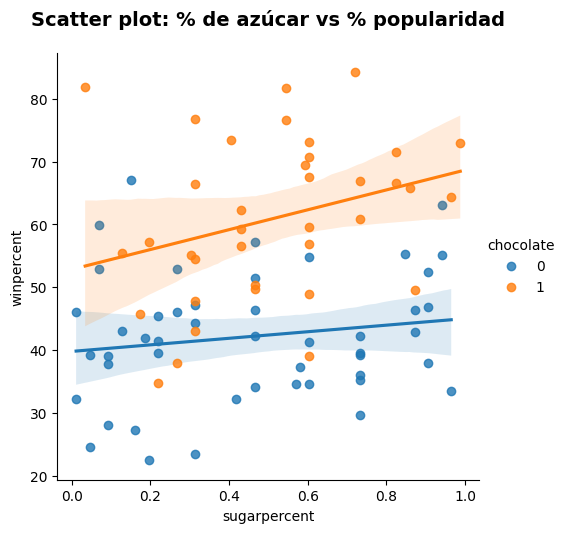

In [4]:
sns.lmplot(x='sugarpercent', y='winpercent', hue='chocolate', data=df_candy)
plt.title('Scatter plot: % de azúcar vs % popularidad', fontsize=14, weight='bold', pad=20)
plt.savefig('scatter_plot.png', dpi=300, bbox_inches='tight')
plt.show()

### Violin plot

In [5]:
def clasificar_dulce(row):
    if row['chocolate'] == 1 and row['peanutyalmondy'] == 1:
        return 'Chocolate + Nueces'
    elif row['chocolate'] == 1:
        return 'Chocolate Simple'
    elif row['fruity'] == 1:
        return 'Frutal'
    elif row['hard'] == 1:
        return 'Duro'
    else:
        return 'Otros'

df_candy['Categoría'] = df_candy.apply(clasificar_dulce, axis=1)

In [6]:
df_candy['Categoría'].value_counts()

Categoría
Frutal                37
Chocolate Simple      25
Chocolate + Nueces    12
Otros                  9
Duro                   2
Name: count, dtype: int64

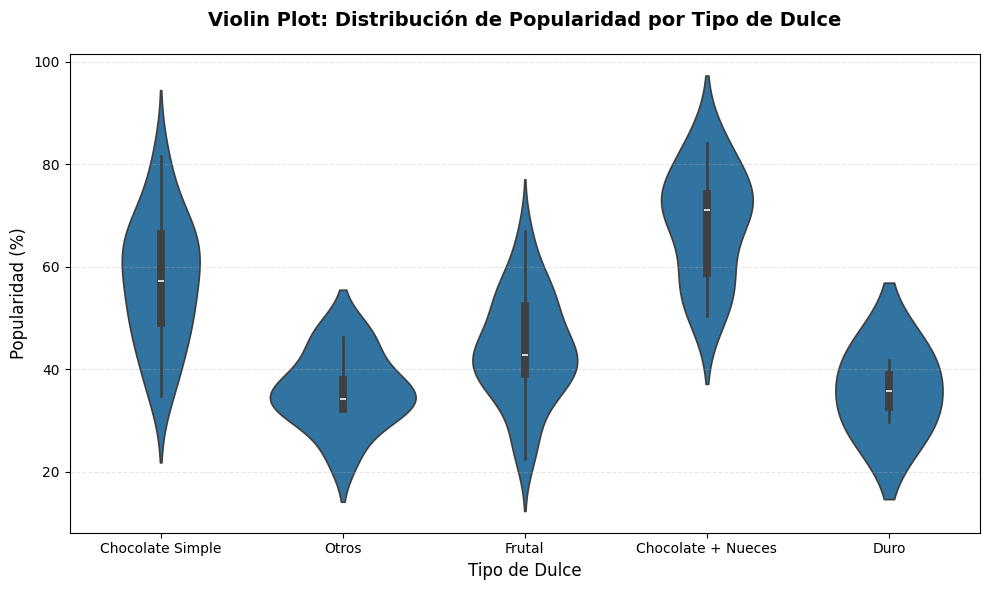

In [7]:
#creamos categorias
df_candy['Tipo'] = df_candy['chocolate'].map({1: 'Con Chocolate', 0: 'Sin Chocolate'})

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_candy, 
               x='Categoría', 
               y='winpercent',
               inner='box')  

plt.title('Violin Plot: Distribución de Popularidad por Tipo de Dulce', 
          fontsize=14, weight='bold', pad=20)
plt.xlabel('Tipo de Dulce', fontsize=12)
plt.ylabel('Popularidad (%)', fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('violin_plot.png', dpi=300, bbox_inches='tight')

### Dendogram

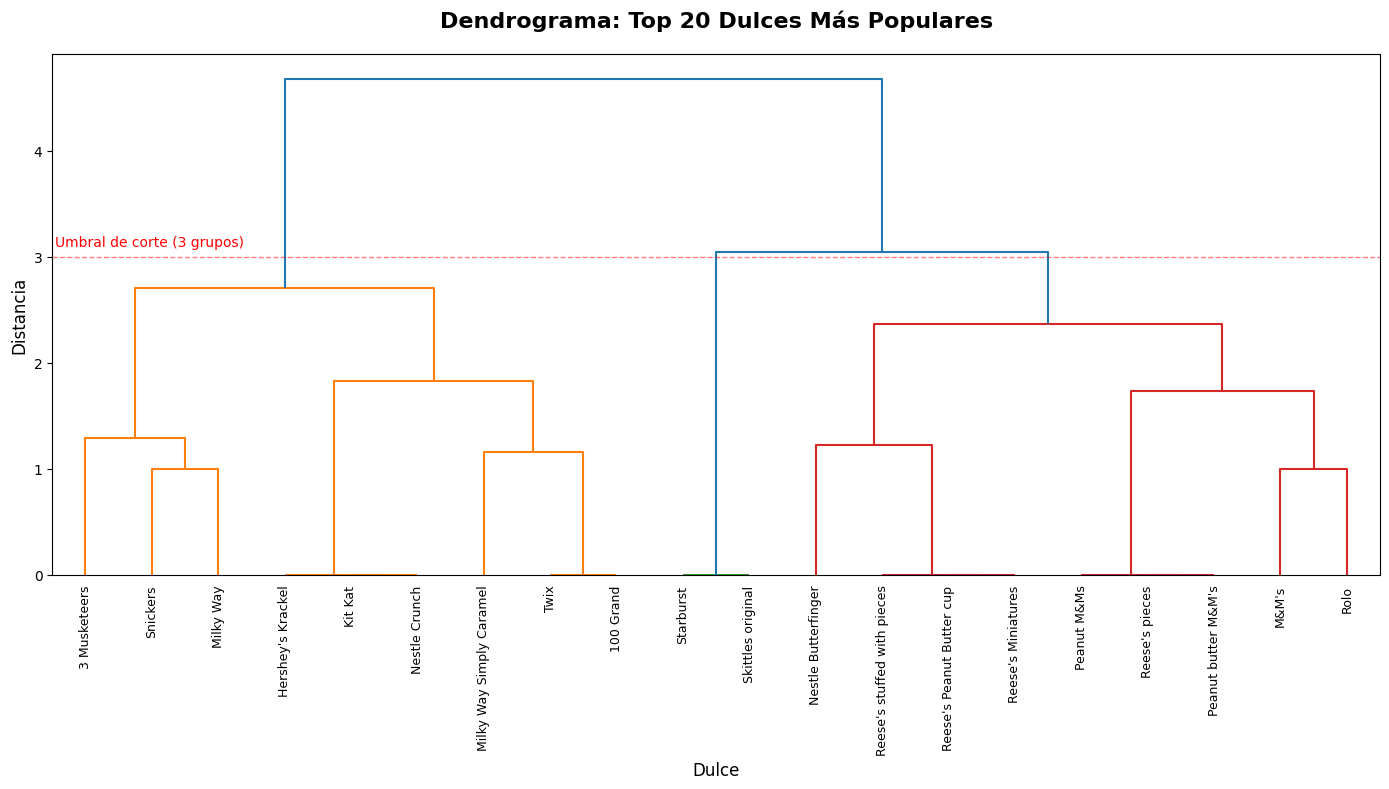

In [8]:
dulces_top = df_candy.nlargest(20, 'winpercent')

# características
caracteristicas = ['chocolate', 'fruity', 'caramel', 'peanutyalmondy', 
                   'nougat', 'crispedricewafer', 'hard', 'bar', 'pluribus']

X = dulces_top[caracteristicas].values
nombres = dulces_top['competitorname'].values

# clustering
linkage_matrix = linkage(X, method='ward')

plt.figure(figsize=(14, 8))
dendro = dendrogram(
    linkage_matrix,
    labels=nombres,
    leaf_rotation=90,
    leaf_font_size=9,
    color_threshold=3,
)

plt.title('Dendrograma: Top 20 Dulces Más Populares', 
          fontsize=16, pad=20, weight='bold')
plt.xlabel('Dulce', fontsize=12)
plt.ylabel('Distancia', fontsize=12)
plt.axhline(y=3, color='red', linestyle='--', linewidth=1, alpha=0.5)
plt.text(0.5, 3.1, 'Umbral de corte (3 grupos)', fontsize=10, color='red')
plt.tight_layout()

plt.savefig('dendrograma.png', dpi=300, bbox_inches='tight')